# Exponential Function Approximation

复现论文[A Flexible Template for Edge Generative AI With High-Accuracy Accelerated Softmax and GELU](https://ieeexplore.ieee.org/document/10971415#sec5)中的指数计算算法

包括**软件模型**与**RTL模型**
- Software模型以原论文为基准，可设置不同的数据类型以达到不同精度
- RTL模型以[论文开源System Verilog代码](https://github.com/belanoa/softex/tree/master/rtl/expu)为基准

同时，对软件模型与硬件模型的实现精度进行了比较

## Software Model

### Standard Exponential Function

In [136]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# Global Configuration for Simulation Precision
SIM_DTYPE = torch.float

print(torch.__version__)
print(plt.__spec__)

2.8.0+cu126
ModuleSpec(name='matplotlib.pyplot', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7b2ee5b07050>, origin='/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py')


The first 100 nums is 
tensor([-10.0000,  -9.9599,  -9.9198,  -9.8798,  -9.8397,  -9.7996,  -9.7595,
         -9.7194,  -9.6794,  -9.6393,  -9.5992,  -9.5591,  -9.5190,  -9.4790,
         -9.4389,  -9.3988,  -9.3587,  -9.3186,  -9.2786,  -9.2385,  -9.1984,
         -9.1583,  -9.1182,  -9.0782,  -9.0381,  -8.9980,  -8.9579,  -8.9178,
         -8.8778,  -8.8377,  -8.7976,  -8.7575,  -8.7174,  -8.6774,  -8.6373,
         -8.5972,  -8.5571,  -8.5170,  -8.4770,  -8.4369,  -8.3968,  -8.3567,
         -8.3166,  -8.2766,  -8.2365,  -8.1964,  -8.1563,  -8.1162,  -8.0762,
         -8.0361,  -7.9960,  -7.9559,  -7.9158,  -7.8758,  -7.8357,  -7.7956,
         -7.7555,  -7.7154,  -7.6754,  -7.6353,  -7.5952,  -7.5551,  -7.5150,
         -7.4749,  -7.4349,  -7.3948,  -7.3547,  -7.3146,  -7.2745,  -7.2345,
         -7.1944,  -7.1543,  -7.1142,  -7.0741,  -7.0341,  -6.9940,  -6.9539,
         -6.9138,  -6.8737,  -6.8337,  -6.7936,  -6.7535,  -6.7134,  -6.6733,
         -6.6333,  -6.5932,  -6.5531,  -6

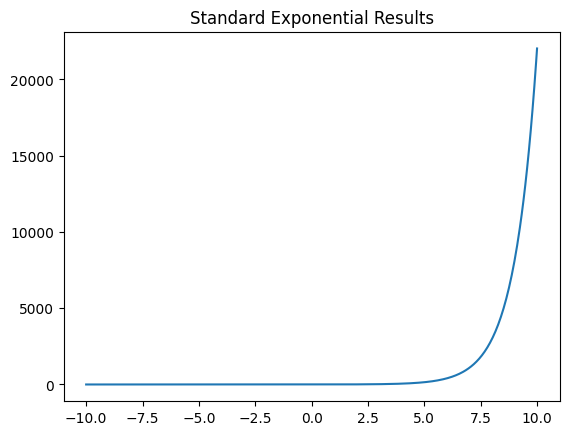

In [137]:
num_2_calc = torch.linspace(start = -10,
                            end = 10,
                            steps = 500,
                            dtype = SIM_DTYPE)
std_exp = torch.exp(num_2_calc) # Remain high accuracy

# Visualize
print(f"The first 100 nums is \n{num_2_calc[:100]} \nTheir standard exponential results is \n{std_exp[:100]}")
plt.title("Standard Exponential Results")
plt.plot(num_2_calc.to(torch.float), std_exp.to(torch.float))
plt.show()

### The Original Schraudolph’s Method

In [138]:
def exps(num_2_calc: torch.Tensor) -> torch.Tensor:
    """
    Returns the Schraudolph’s Method results that is an approximation of standard exponentiation.

    Args:
        num_2_calc: The number to be calculated.
    """
    # Parameter
    ln2_inversed = 1 / torch.log(torch.tensor(2.0, dtype = SIM_DTYPE))

    x = num_2_calc * ln2_inversed
    x_int = torch.floor(x)
    x_frac = x - x_int
    exps = (2 ** x_int) * (1 + x_frac)
    return exps

torch.float32


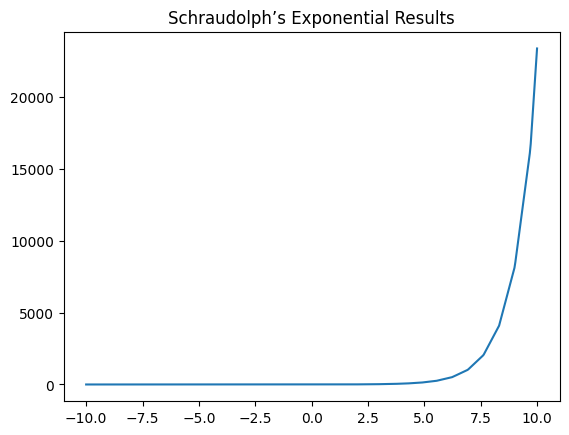

In [139]:
schraudolph_exp = exps(num_2_calc)
# Visualize
print(schraudolph_exp.dtype)
plt.title("Schraudolph’s Exponential Results")
plt.plot(num_2_calc.to(torch.float), schraudolph_exp.to(torch.float))

### The EXPP

In [ ]:
def expp(num_2_calc: torch.Tensor) -> torch.Tensor:
    """
    Returns the EXPP Method results that is a more accurate approximation of standard exponentiation.

    Args:
        num_2_calc: The number to be calculated.
    """
    # Parameter
    ln2_inversed = 1 / torch.log(torch.tensor(2.0, dtype = SIM_DTYPE))
    # 这一部分在RTL实现中是采用定点数存储&计算的，精度大概有Q<2.21>，所以这里用float64来模拟
    alpha = 0.21875
    beta = 0.4375
    gamma_1 = 3.296875
    gamma_2 = 2.171875
    P = []

    x = num_2_calc * ln2_inversed
    x_int = torch.floor(x)
    x_frac = x - x_int

    # The correction polynomial P(x)
    p_high = 1 - beta * (1 - x_frac) * (x_frac + gamma_2) # For x >= 0.5
    p_low = alpha * x_frac * (x_frac + gamma_1)           # For x < 0.5
    P = torch.where(condition = x_frac >= 0.5,
                    input = p_high,
                    other = p_low)

    # The final results
    expp = (2 ** x_int) * (1 + P)
    return expp

torch.float32


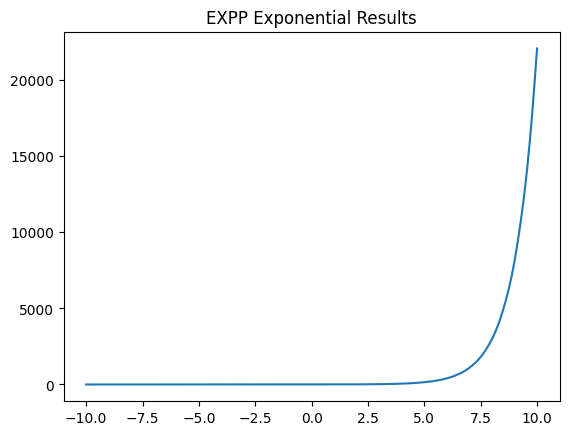

In [141]:
expp_exp = expp(num_2_calc)
# Visualize
print(expp_exp.dtype)
plt.title("EXPP Exponential Results")
plt.plot(num_2_calc.to(torch.float), expp_exp.to(torch.float))

### Experiments
Show relative and absolute errors of the above algorithms.

The algorithm precision configuration is **torch.float32**. Simulation finished.
The mean relative error of EXPP is 0.0016447198577225208.
The mean relative error of EXPS is 0.04062677174806595.
The max relative error of EXPP is 0.0040312260389328.
The max relative error of EXPS is 0.061475351452827454.


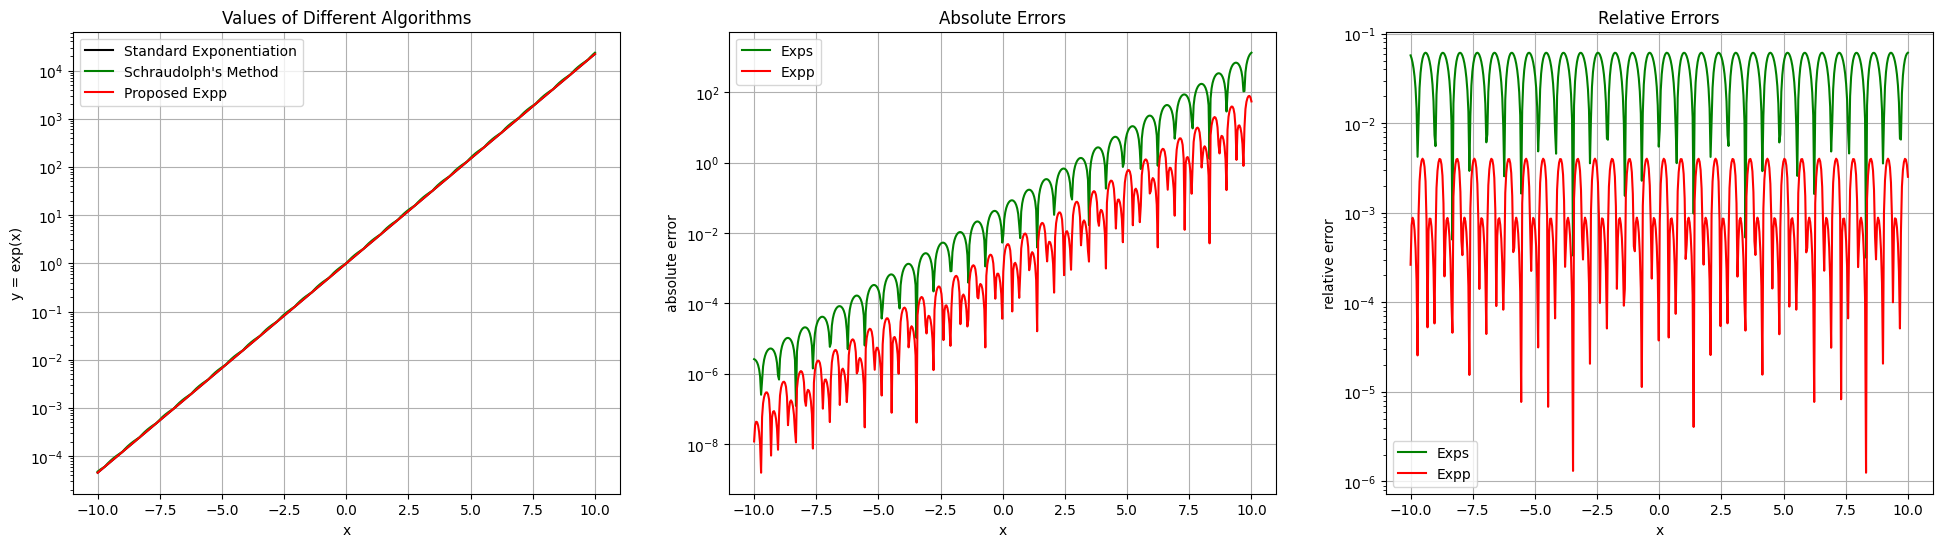

In [142]:
# 1. Absolute errors
exps_abs_error = torch.absolute(schraudolph_exp - std_exp)
expp_abs_error = torch.absolute(expp_exp - std_exp)

# 2. Relative errors
exps_rel_error = exps_abs_error / torch.absolute(std_exp)
expp_rel_error = expp_abs_error / torch.absolute(std_exp)

# 3. Visualize
plt.figure(figsize=(24, 6))

plt.subplot(1, 3, 1)
plt.plot(num_2_calc.to(torch.float),
         std_exp.to(torch.float),
         'black',
         label = 'Standard Exponentiation')
plt.plot(num_2_calc.to(torch.float),
         schraudolph_exp.to(torch.float),
         'green',
         label = "Schraudolph's Method")
plt.plot(num_2_calc.to(torch.float),
         expp_exp.to(torch.float),
         'red',
         label = "Proposed Expp")
plt.legend()
plt.grid(True)
plt.title("Values of Different Algorithms")
plt.xlabel("x")
plt.ylabel("y = exp(x)")
plt.yscale("log")

plt.subplot(1, 3, 2)
plt.plot(num_2_calc.to(torch.float),
         exps_abs_error.to(torch.float),
         'green',
         label = 'Exps')
plt.plot(num_2_calc.to(torch.float),
         expp_abs_error.to(torch.float),
         'red',
         label = "Expp")
plt.legend()
plt.grid(True)
plt.title("Absolute Errors")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.yscale("log")

plt.subplot(1, 3, 3)
plt.plot(num_2_calc.to(torch.float),
         exps_rel_error.to(torch.float),
         'green',
         label = 'Exps')
plt.plot(num_2_calc.to(torch.float),
         expp_rel_error.to(torch.float),
         'red',
         label = "Expp")
plt.legend()
plt.grid(True)
plt.title("Relative Errors")
plt.xlabel("x")
plt.ylabel("relative error")
plt.yscale("log")

# 4. Print key info
print(f"The algorithm precision configuration is **{SIM_DTYPE}**. Simulation finished.")
print(f"The mean relative error of EXPP is {torch.mean(expp_rel_error)}.")
print(f"The mean relative error of EXPS is {torch.mean(exps_rel_error)}.")
print(f"The max relative error of EXPP is {torch.max(expp_rel_error)}.")
print(f"The max relative error of EXPS is {torch.max(exps_rel_error)}.")

## RTL Model

### `expu_schraudolph.sv`

In [143]:
#* Hyperparameters for RTL implementation reference
FPFORMAT = "BF16"
A_FRACTION = 14         # Number of fractional bits for 1/ln2
A_INT = 1               # Number of integer bits for 1/ln2
ENABLE_ROUNDING = True  # Whether to enable rounding in fixed-point operations
WIDTH = 16              # Total bit-width for fixed-point representation
MANTISSA_BITS = 7
EXPONENT_BITS = 8
BIAS = 127              # BF16 parameters
MANTISSA_INT_BITS = 1   # Number of integer bits in mantissa in fixed-point format
MAX_EXP = 133

In [144]:
def rtl_expu_schraudolph(input: int) -> int:
    """
    RTL Model of Schraudolph's Exponential Approximation Method.

    Args:
        input: The input number in fixed-point representation.
    
    Returns:
        The approximated exponential result in fixed-point representation.
    """
    #* Represent 1/ln2 in Q<1.14> fixed point format
    a_ln2_inversed_fixed = round((1 / math.log(2)) * (2 ** A_FRACTION))

    sign = (input >> 15) & 0x01         # Extract sign bit msb
    exponent = (input >> 7) & 0xff      # Extract exponent bits
    mantissa = (input & 0x7f) | 0x80    # Extract mantissa bits and add implicit leading one
    # print(f"The extracted sign of input number is {sign}, exponent is {exponent}, mantissa is {mantissa}.")

    scaled_mantissa = mantissa * a_ln2_inversed_fixed
    # print(f"The scaled mantissa is {scaled_mantissa}.")

    shifted_mantissa = ((scaled_mantissa >> 7) & 0xffff) >> max(0, (MAX_EXP - exponent))
    # print(f"The shifted mantissa is {shifted_mantissa}.")
    
    rounded_mantissa = (shifted_mantissa >> 1) + (shifted_mantissa & 0x01 if ENABLE_ROUNDING else 0)
    # print(f"The rounded mantissa is {rounded_mantissa}.")

    signed_mantissa = (~rounded_mantissa + 1) & 0x7fff if sign == 1 else rounded_mantissa
    # print(f"The signed mantissa is {signed_mantissa}.")

    ovfr = exponent > MAX_EXP or (
        (exponent == MAX_EXP) and (
            ((scaled_mantissa >> 22) & 0x01) or (
                sign and (
                    ((scaled_mantissa >> 14) & 0xff) == 0xff
                )
            )
        )
    )
    denormal = sign and (exponent == MAX_EXP) and ((signed_mantissa >> 7) & 0xFF) == 0x81

    #* Output logic
    if not ovfr and not denormal:
        new_exp = ((signed_mantissa >> 7) & 0xff) + BIAS
        new_man = signed_mantissa & 0x7f
    else:
        new_exp = 0xff if not sign else 0
        new_man = 0

    output = (0 << 15) | ((new_exp & 0xff) << 7) | (new_man & 0x7f)

    return output

In [145]:
# 测试用例
# 1.0 (0x3F80) -> exp(1.0) ≈ 2.718 (0x402D)
input_val = 0x3F80 
output_val = rtl_expu_schraudolph(input_val)
print(f"Input: 0x{input_val:04X}, Output: 0x{output_val:04X}")

Input: 0x3F80, Output: 0x4039


### `expu_correction.sv`

In [146]:
#* Hyperparameters
COEFFICIENT_FRACTION = 4
CONSTANT_FRACTION = 7
MUL_SURPLUS_BITS = 1
NOT_SURPLUS_BITS = 0
ALPHA_FIXED = 4
BETA_FIXED = 7
GAMMA_1_FIXED = 363
GAMMA_2_FIXED = 278

In [147]:
def rtl_expu_correction(input: int) -> int:
    """
    RTL Model of EXPP's Correction Polynomial.

    Args:
        input: The output of `rtl_expu_schraudolph()` in fixed-point representation.
    
    Returns:
        The correction polynomial result in fixed-point representation.
    """
    exponent = (input >> 7) & 0xff      # Extract exponent bits
    mantissa = (input & 0x7f) | 0x80    # Extract mantissa bits and add implicit leading one

    msb_mantissa = (mantissa >> 6) & 0x01
    # print(f"The msb of mantissa is {msb_mantissa}.")

    mant_mul_1 = (mantissa << 1) & 0x7e if not msb_mantissa else (~((mantissa << 1) & 0xfe)) & 0x7F
    alpha_beta_mul_1 = ALPHA_FIXED if not msb_mantissa else BETA_FIXED

    res_mul_1 = mant_mul_1 * alpha_beta_mul_1

    mant_add_1 = mantissa & 0x7f
    # 注意位宽，得把mantissa最高位的隐含1去掉
    gamma_add_1 = GAMMA_1_FIXED if not msb_mantissa else GAMMA_2_FIXED
    res_add_1 = mant_add_1 + gamma_add_1

    res_mul_2 = res_mul_1 * res_add_1

    res_pre_inversion = res_mul_2 >> 12

    corrected_mantissa = (~res_pre_inversion) & 0x7F if msb_mantissa else res_pre_inversion
    # print(f"The corrected mantissa is {corrected_mantissa}.")

    output = (0 << 15) | (exponent << 7) | (corrected_mantissa & 0x7f)

    return output

In [148]:
# 测试用例
# 1.0 (0x3F80) -> exp(1.0) ≈ 2.718 (0x402D or close)
input_val = 0x4000
output_val = rtl_expu_schraudolph(input_val)
print(f"Input: 0x{input_val:04X}, Output: 0x{output_val:04X}")
output_val_corrected = rtl_expu_correction(output_val)
print(f"Corrected Output: 0x{output_val_corrected:04X}")

Input: 0x4000, Output: 0x40F1
Corrected Output: 0x40EC


## Experiments

比较Software Model与RTL Model的计算精度

In [149]:
# 准备BF16-INT转换函数
# Thanks to Gemini 3.0
import struct

def float_to_bf16_int(value: float) -> int:
    """
    将 Python 浮点数转换为 BF16 格式的 16 位整数 (Bit Pattern)。
    原理：Float32 -> Bytes -> 取高 16 位 -> Int
    """
    # 1. 将 float 打包成 IEEE 754 32位浮点数的二进制数据 (4 bytes)
    # '!' 代表网络字节序 (Big-Endian)，保证高位字节在前
    # 'f' 代表 float (32-bit)
    packed = struct.pack('!f', value)
    
    # 2. 提取高 16 位 (前两个字节)
    # BF16 实际上就是 FP32 丢弃低 16 位尾数的结果
    # 'H' 代表 unsigned short (16-bit integer)
    integer_val = struct.unpack('!H', packed[:2])[0]
    
    return integer_val

def bf16_int_to_float(value: int) -> float:
    """
    将 BF16 格式的 16 位整数重新解释为 Python 浮点数。
    原理：Int16 -> 补零至 32 位 -> Bytes -> Float32
    """
    # 1. 将 16 位整数左移 16 位，恢复为 32 位整数的“形状”
    # 低 16 位补 0 (相当于尾数部分置零)
    value_32 = value << 16
    
    # 2. 将 32 位整数打包成二进制数据
    # 'I' 代表 unsigned int (32-bit)
    packed = struct.pack('!I', value_32)
    
    # 3. 将二进制数据解包为 float
    float_val = struct.unpack('!f', packed)[0]
    
    return float_val

In [150]:
rtl_input = num_2_calc.tolist()
rtl_exps = []
rtl_expp = []

for val in rtl_input:
    #* Step 1: Convert float to BF16 int representation
    rtl_input_fixed = float_to_bf16_int(val)

    #* Step 2: RTL Schraudolph Exponential Approximation
    rtl_output_schraudolph = rtl_expu_schraudolph(rtl_input_fixed)
    rtl_output_correction = rtl_expu_correction(rtl_output_schraudolph)

    #* Step 3: Convert BF16 int representation back to float
    rtl_output_schraudolph_float = bf16_int_to_float(rtl_output_schraudolph)
    rtl_output_correction_float = bf16_int_to_float(rtl_output_correction)
    rtl_exps.append(rtl_output_schraudolph_float)
    rtl_expp.append(rtl_output_correction_float)

print(f"The first 10 RTL Schraudolph outputs are {rtl_exps[:10]}")
print(f"The first 10 RTL EXPP corrected outputs are {rtl_expp[:10]}")

The first 10 RTL Schraudolph outputs are [4.792213439941406e-05, 5.078315734863281e-05, 5.340576171875e-05, 5.340576171875e-05, 5.626678466796875e-05, 5.91278076171875e-05, 5.91278076171875e-05, 6.246566772460938e-05, 6.818771362304688e-05, 6.818771362304688e-05]
The first 10 RTL EXPP corrected outputs are [4.5299530029296875e-05, 4.839897155761719e-05, 5.125999450683594e-05, 5.125999450683594e-05, 5.4836273193359375e-05, 5.841255187988281e-05, 5.841255187988281e-05, 6.198883056640625e-05, 6.628036499023438e-05, 6.628036499023438e-05]


The algorithm precision configuration is **torch.float32**. Simulation finished.
The mean relative error of EXPP is 0.0016447198577225208.
The mean relative error of EXPS is 0.04062677174806595.
The max relative error of EXPP is 0.0040312260389328.
The max relative error of EXPS is 0.061475351452827454.
The mean relative error of RTL EXPP is 0.014500997960567474.
The mean relative error of RTL EXPS is 0.04293683543801308.
The max relative error of RTL EXPP is 0.06428834795951843.
The max relative error of RTL EXPS is 0.12189054489135742.


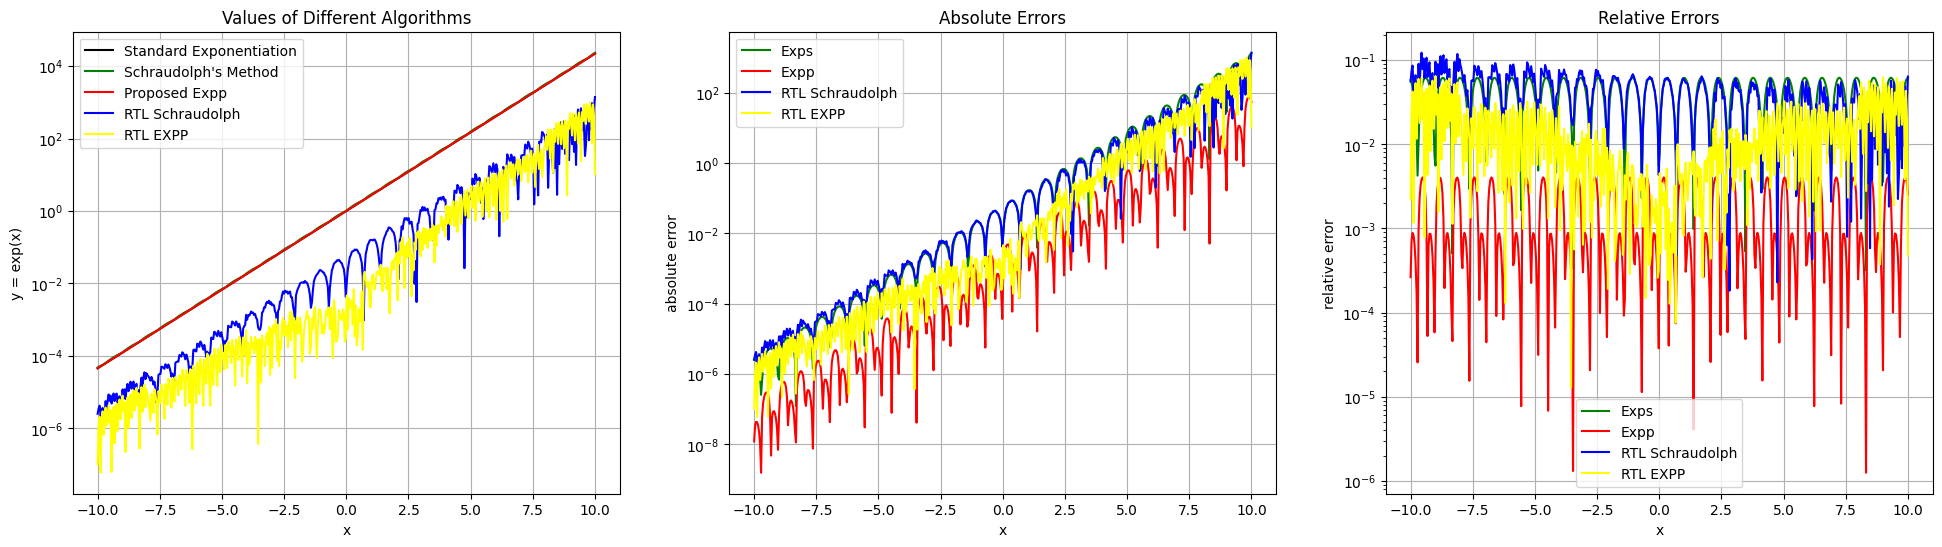

In [151]:
# 1. Absolute errors
exps_abs_error = torch.absolute(schraudolph_exp - std_exp)
expp_abs_error = torch.absolute(expp_exp - std_exp)
rtl_exps_abs_error = torch.absolute(torch.tensor(rtl_exps, dtype = SIM_DTYPE) - std_exp)
rtl_expp_abs_error = torch.absolute(torch.tensor(rtl_expp, dtype = SIM_DTYPE) - std_exp)

# 2. Relative errors
exps_rel_error = exps_abs_error / torch.absolute(std_exp)
expp_rel_error = expp_abs_error / torch.absolute(std_exp)
rtl_exps_rel_error = rtl_exps_abs_error / torch.absolute(std_exp)
rtl_expp_rel_error = rtl_expp_abs_error / torch.absolute(std_exp)

# 3. Visualize
plt.figure(figsize=(24, 6))

plt.subplot(1, 3, 1)
plt.plot(num_2_calc.to(torch.float),
         std_exp.to(torch.float),
         'black',
         label = 'Standard Exponentiation')
plt.plot(num_2_calc.to(torch.float),
         schraudolph_exp.to(torch.float),
         'green',
         label = "Schraudolph's Method")
plt.plot(num_2_calc.to(torch.float),
         expp_exp.to(torch.float),
         'red',
         label = "Proposed Expp")
plt.plot(num_2_calc.to(torch.float),
         rtl_exps_abs_error.to(torch.float),
         'blue',
         label = "RTL Schraudolph")
plt.plot(num_2_calc.to(torch.float),
         rtl_expp_abs_error.to(torch.float),
         'yellow',
         label = "RTL EXPP")

plt.legend()
plt.grid(True)
plt.title("Values of Different Algorithms")
plt.xlabel("x")
plt.ylabel("y = exp(x)")
plt.yscale("log")

plt.subplot(1, 3, 2)
plt.plot(num_2_calc.to(torch.float),
         exps_abs_error.to(torch.float),
         'green',
         label = 'Exps')
plt.plot(num_2_calc.to(torch.float),
         expp_abs_error.to(torch.float),
         'red',
         label = "Expp")
plt.plot(num_2_calc.to(torch.float),
         rtl_exps_abs_error.to(torch.float),
         'blue',
         label = "RTL Schraudolph")
plt.plot(num_2_calc.to(torch.float),
         rtl_expp_abs_error.to(torch.float),
         'yellow',
         label = "RTL EXPP")

plt.legend()
plt.grid(True)
plt.title("Absolute Errors")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.yscale("log")

plt.subplot(1, 3, 3)
plt.plot(num_2_calc.to(torch.float),
         exps_rel_error.to(torch.float),
         'green',
         label = 'Exps')
plt.plot(num_2_calc.to(torch.float),
         expp_rel_error.to(torch.float),
         'red',
         label = "Expp")
plt.plot(num_2_calc.to(torch.float),
         rtl_exps_rel_error.to(torch.float),
         'blue',
         label = "RTL Schraudolph")
plt.plot(num_2_calc.to(torch.float),
         rtl_expp_rel_error.to(torch.float),
         'yellow',
         label = "RTL EXPP")

plt.legend()
plt.grid(True)
plt.title("Relative Errors")
plt.xlabel("x")
plt.ylabel("relative error")
plt.yscale("log")

# 4. Print key info
print(f"The algorithm precision configuration is **{SIM_DTYPE}**. Simulation finished.")
print(f"The mean relative error of EXPP is {torch.mean(expp_rel_error)}.")
print(f"The mean relative error of EXPS is {torch.mean(exps_rel_error)}.")
print(f"The max relative error of EXPP is {torch.max(expp_rel_error)}.")
print(f"The max relative error of EXPS is {torch.max(exps_rel_error)}.")
print(f"The mean relative error of RTL EXPP is {torch.mean(rtl_expp_rel_error)}.")
print(f"The mean relative error of RTL EXPS is {torch.mean(rtl_exps_rel_error)}.")
print(f"The max relative error of RTL EXPP is {torch.max(rtl_expp_rel_error)}.")
print(f"The max relative error of RTL EXPS is {torch.max(rtl_exps_rel_error)}.")

The mean relative error of EXPP is 0.0016447198577225208.
The mean relative error of RTL EXPP is 0.014500997960567474.
The max relative error of EXPP is 0.0040312260389328.
The max relative error of RTL EXPP is 0.06428834795951843.


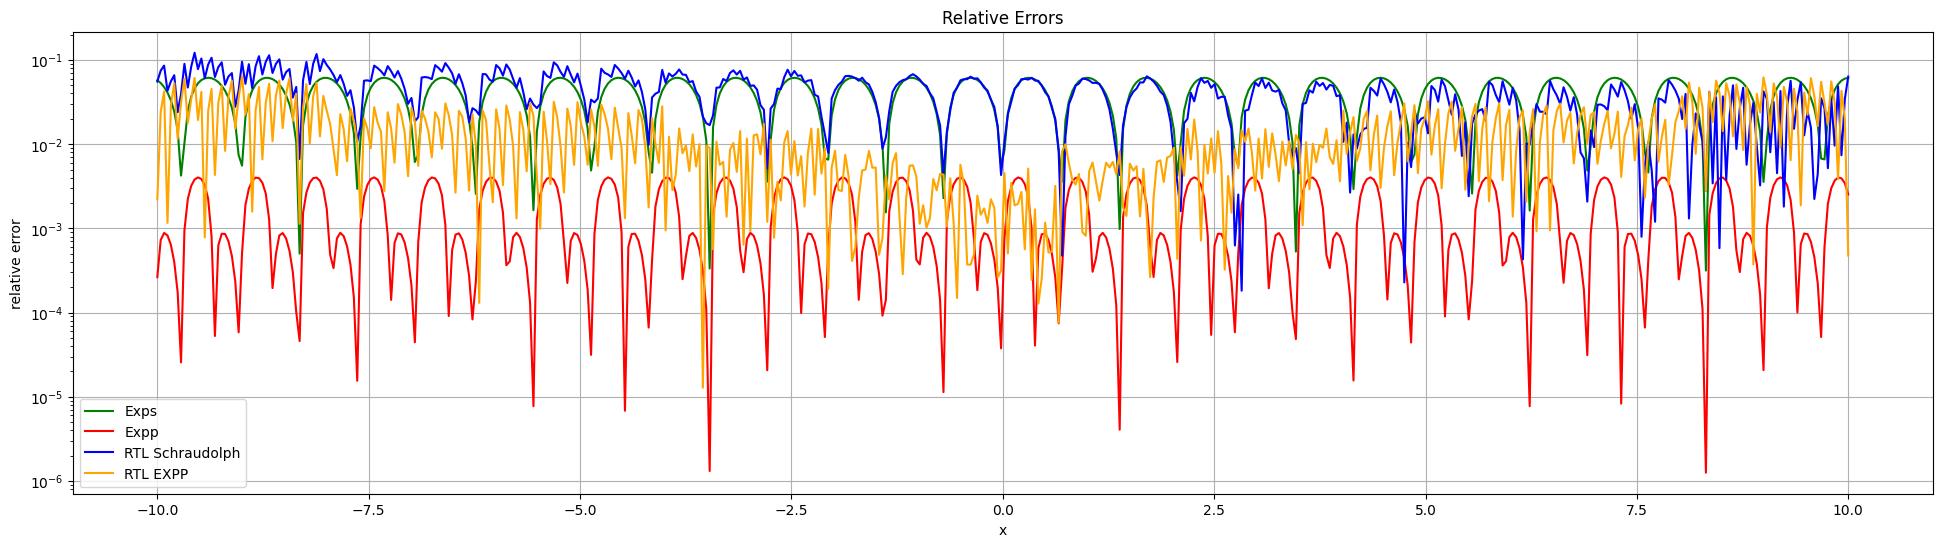

In [152]:
# 单独画一下相对误差
plt.figure(figsize=(24, 6))
plt.plot(num_2_calc.to(torch.float),
         exps_rel_error.to(torch.float),
         'green',
         label = 'Exps')
plt.plot(num_2_calc.to(torch.float),
         expp_rel_error.to(torch.float),
         'red',
         label = "Expp")
plt.plot(num_2_calc.to(torch.float),
         rtl_exps_rel_error.to(torch.float),
         'blue',
         label = "RTL Schraudolph")
plt.plot(num_2_calc.to(torch.float),
         rtl_expp_rel_error.to(torch.float),
         'orange',
         label = "RTL EXPP")

plt.legend()
plt.grid(True)
plt.title("Relative Errors")
plt.xlabel("x")
plt.ylabel("relative error")
plt.yscale("log")

print(f"The mean relative error of EXPP is {torch.mean(expp_rel_error)}.")
print(f"The mean relative error of RTL EXPP is {torch.mean(rtl_expp_rel_error)}.")
print(f"The max relative error of EXPP is {torch.max(expp_rel_error)}.")
print(f"The max relative error of RTL EXPP is {torch.max(rtl_expp_rel_error)}.")